In [1]:
import yfinance as yf

# Download Apple stock data
df = yf.download("AAPL",
                 start="2021-06-09",
                 end="2026-06-09")

# Save to CSV
df.to_csv("APPL.csv")

print(df.head())

[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open    Volume
Ticker            AAPL        AAPL        AAPL        AAPL      AAPL
Date                                                                
2021-06-09  123.920227  124.524576  123.325628  123.998209  56877900
2021-06-10  122.925957  124.953442  122.760251  123.812977  71186400
2021-06-11  124.134666  124.222398  122.916226  123.335370  53522400
2021-06-14  127.185600  127.244083  123.861701  124.592765  96906500
2021-06-15  126.366844  127.302613  126.123156  126.659273  62746300


In [2]:
df.columns = df.columns.get_level_values(0)

print(df.head())

Price            Close        High         Low        Open    Volume
Date                                                                
2021-06-09  123.920227  124.524576  123.325628  123.998209  56877900
2021-06-10  122.925957  124.953442  122.760251  123.812977  71186400
2021-06-11  124.134666  124.222398  122.916226  123.335370  53522400
2021-06-14  127.185600  127.244083  123.861701  124.592765  96906500
2021-06-15  126.366844  127.302613  126.123156  126.659273  62746300


In [3]:
df.to_csv("apple_stock.csv")

In [4]:
import os
print(os.getcwd())

C:\Users\adero\AnalystLab Africa\Week 6



**Data Familiarization**


In [5]:
# Import required libraries for data analysis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df.head(10)

Price,Close,High,Low,Open,Volume
Date,,,,,
2021-06-09,123.920227,124.524576,123.325628,123.998209,56877900
2021-06-10,122.925957,124.953442,122.760251,123.812977,71186400
2021-06-11,124.134666,124.222398,122.916226,123.335370,53522400
2021-06-14,127.185600,127.244083,123.861701,124.592765,96906500
2021-06-15,126.366844,127.302613,126.123156,126.659273,62746300
2021-06-16,126.863953,127.585274,125.216634,127.078399,91815000
2021-06-17,128.462540,129.203361,126.376571,126.522793,96721700
2021-06-18,127.166153,128.189631,126.951706,127.409841,108953300
2021-06-21,128.959641,129.066864,125.947662,127.010137,79663300


In [7]:
# Display the number of rows and columns in the dataset
df.shape

(1255, 5)

In [8]:
# Generate descriptive statistics for numerical columns
df.describe()

Price,Close,High,Low,Open,Volume
count,1255.000000,1255.000000,1255.000000,1255.000000,1.255000e+03
mean,191.716371,193.602674,189.652021,191.512973,6.535338e+07
std,44.022089,44.363710,43.694423,44.018308,2.818017e+07
min,122.925957,124.222398,122.097730,123.335370,1.791060e+07
25%,154.339867,156.920478,151.926123,154.870487,4.615660e+07
50%,180.775681,182.657852,179.321280,180.674174,5.780870e+07
75%,225.504410,227.423464,223.152922,225.535483,7.759175e+07
max,315.200012,317.399994,309.649994,314.179993,3.186799e+08


In [9]:
# Identify missing values in each column
df.isnull().sum()

Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [10]:
# Count duplicate rows in the dataset
df.duplicated().sum()

np.int64(0)

In [11]:
# Display the data type of each column
df.dtypes

Price
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object

In [12]:
# Display the dataframe index
df.index

DatetimeIndex(['2021-06-09', '2021-06-10', '2021-06-11', '2021-06-14',
               '2021-06-15', '2021-06-16', '2021-06-17', '2021-06-18',
               '2021-06-21', '2021-06-22',
               ...
               '2026-05-26', '2026-05-27', '2026-05-28', '2026-05-29',
               '2026-06-01', '2026-06-02', '2026-06-03', '2026-06-04',
               '2026-06-05', '2026-06-08'],
              dtype='datetime64[s]', name='Date', length=1255, freq=None)

In [13]:
# Calculate the difference between consecutive trading dates
df.index.to_series().diff().value_counts().sort_index()

Date
1 days    979
2 days     14
3 days    226
4 days     35
Name: count, dtype: int64

In [14]:
# Display the earliest date in the dataset
df.index.min()

Timestamp('2021-06-09 00:00:00')

In [15]:
# Display the latest date in the dataset
df.index.max()

Timestamp('2026-06-08 00:00:00')

In [16]:
# Calculate the total duration covered by the dataset
df.index.max() - df.index.min()

Timedelta('1825 days 00:00:00')

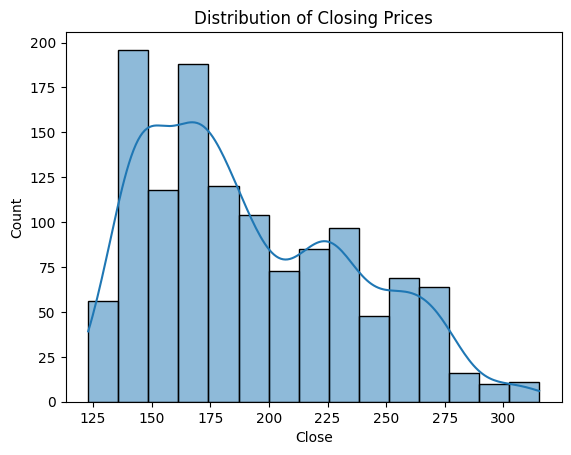

In [17]:
# Visualize the distribution of closing prices
sns.histplot(df['Close'], kde=True)
plt.title('Distribution of Closing Prices')
plt.show()

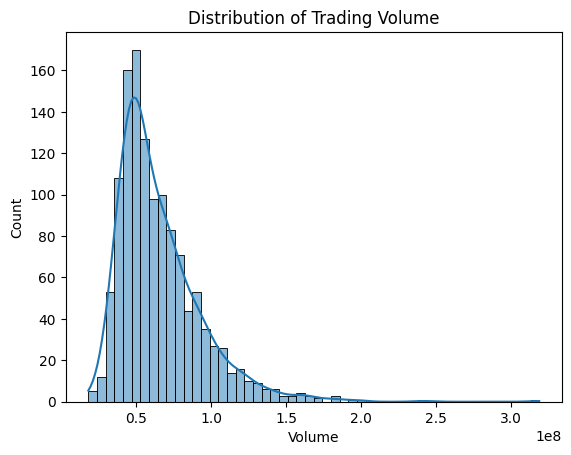

In [18]:
# Visualize the distribution of trading volume
sns.histplot(df['Volume'], kde=True)
plt.title('Distribution of Trading Volume')
plt.show()

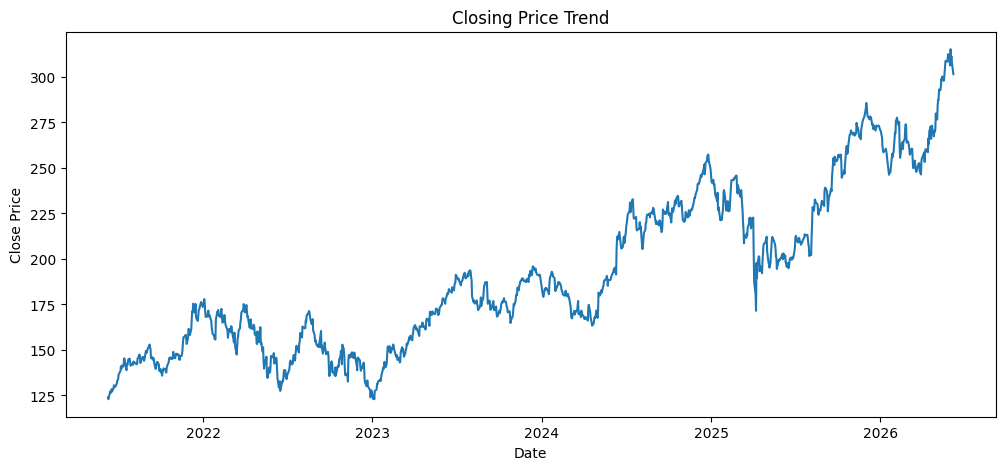

In [19]:
# Plot the closing price trend over time
plt.figure(figsize=(12,5))
plt.plot(df.index, df['Close'])
plt.title('Closing Price Trend')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.show()

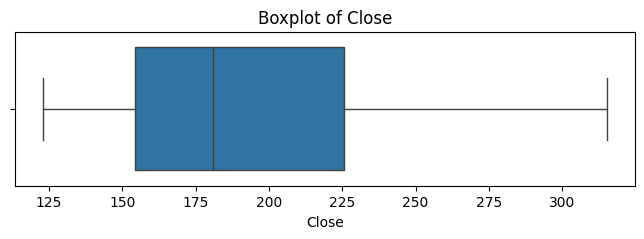

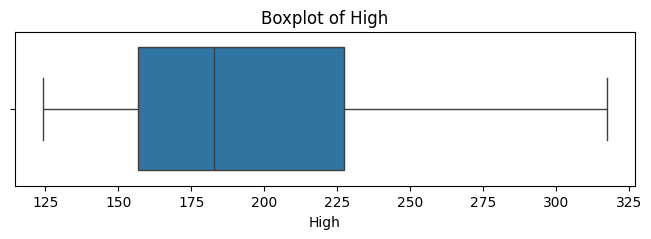

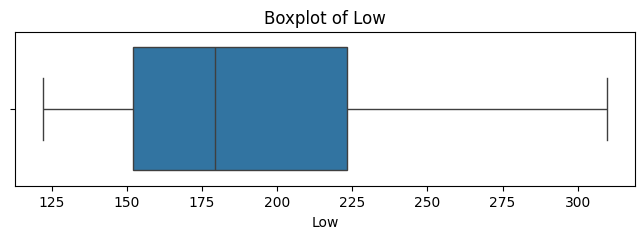

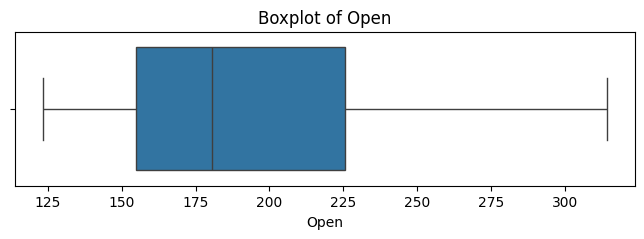

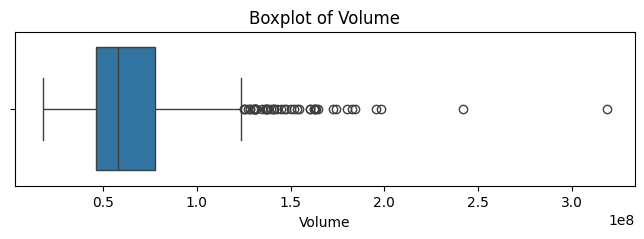

In [20]:
# Visualize potential outliers in stock prices and volume
for col in df.columns:
    plt.figure(figsize=(8,2))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

**Data Cleaning**

In [21]:
# Check whether dates are sorted in ascending order
df.index.is_monotonic_increasing

True

In [22]:
# Check for negative stock prices
(df[['Open','High','Low','Close']] < 0).sum()

Price
Open     0
High     0
Low      0
Close    0
dtype: int64

In [23]:
# Check for negative trading volume
(df['Volume'] < 0).sum()

np.int64(0)

In [24]:
# Identify records where High is less than Low
(df['High'] < df['Low']).sum()

np.int64(0)

In [25]:
# Identify records where Open falls outside the daily range
((df['Open'] > df['High']) | (df['Open'] < df['Low'])).sum()

np.int64(0)

In [26]:
# Identify records where Close falls outside the daily range
((df['Close'] > df['High']) | (df['Close'] < df['Low'])).sum()

np.int64(0)

**Data Transformation**

In [27]:
# Calculate the difference between the daily high and low prices
df['Trading_Range'] = df['High'] - df['Low']

In [28]:
# Calculate the difference between closing and opening prices
df['Daily_Price_Change'] = df['Close'] - df['Open']

In [29]:
# Calculate percentage change between opening and closing prices
df['Pct_Price_Change'] = (
    (df['Close'] - df['Open']) / df['Open']
) * 100

In [30]:
# Calculate daily returns based on consecutive closing prices
df['Daily_Return'] = (
    df['Close'].pct_change()
) * 100

In [31]:
# Extract year from the date index
df['Year'] = df.index.year

In [32]:
# Extract month number from the date index
df['Month_Num'] = df.index.month

In [33]:
# Extract month name from the date index
df['Month'] = df.index.month_name()

In [34]:
# Extract quarter from the date index
df['Quarter'] = df.index.quarter

In [35]:
# Extract weekday name from the date index
df['Day_Name'] = df.index.day_name()

In [36]:
# Display the first five rows with engineered features
df.head()

Price,Close,High,Low,Open,Volume,Trading_Range,Daily_Price_Change,Pct_Price_Change,Daily_Return,Year,Month_Num,Month,Quarter,Day_Name
Date,,,,,,,,,,,,,,
2021-06-09,123.920227,124.524576,123.325628,123.998209,56877900,1.198948,-0.077982,-0.062890,NaN,2021,6,June,2,Wednesday
2021-06-10,122.925957,124.953442,122.760251,123.812977,71186400,2.193192,-0.887020,-0.716420,-0.802347,2021,6,June,2,Thursday
2021-06-11,124.134666,124.222398,122.916226,123.335370,53522400,1.306172,0.799296,0.648067,0.983283,2021,6,June,2,Friday
2021-06-14,127.185600,127.244083,123.861701,124.592765,96906500,3.382382,2.592836,2.081048,2.457761,2021,6,June,2,Monday
2021-06-15,126.366844,127.302613,126.123156,126.659273,62746300,1.179456,-0.292429,-0.230878,-0.643749,2021,6,June,2,Tuesday


In [37]:
# Generate summary statistics for engineered features
df[['Trading_Range',
    'Daily_Price_Change',
    'Pct_Price_Change',
    'Daily_Return']].describe()

Price,Trading_Range,Daily_Price_Change,Pct_Price_Change,Daily_Return
count,1255.000000,1255.000000,1255.000000,1254.000000
mean,3.950652,0.203398,0.122508,0.085841
std,2.236866,2.750008,1.474054,1.731251
min,0.950458,-14.204942,-7.648634,-9.245612
25%,2.525099,-1.229575,-0.631985,-0.758856
50%,3.426089,0.198279,0.104011,0.113717
75%,4.756096,1.638563,0.902877,0.962714
max,28.569050,26.758623,15.644088,15.328863


**Time-Series Analysis**

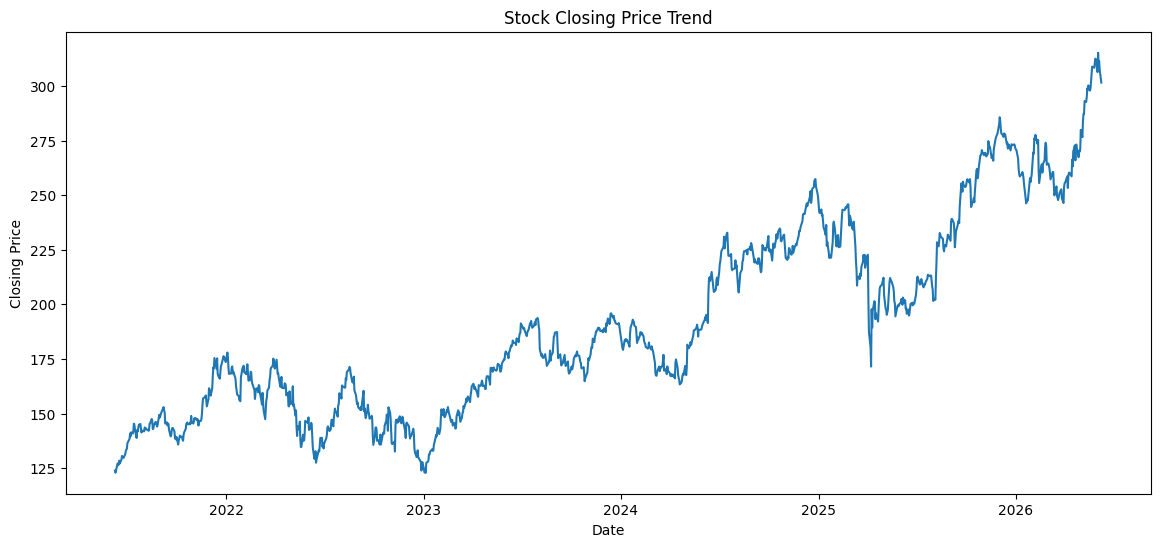

In [38]:
# Visualize stock closing price over time
plt.figure(figsize=(14,6))
plt.plot(df.index, df['Close'])

plt.title('Stock Closing Price Trend')
plt.xlabel('Date')
plt.ylabel('Closing Price')

plt.show()

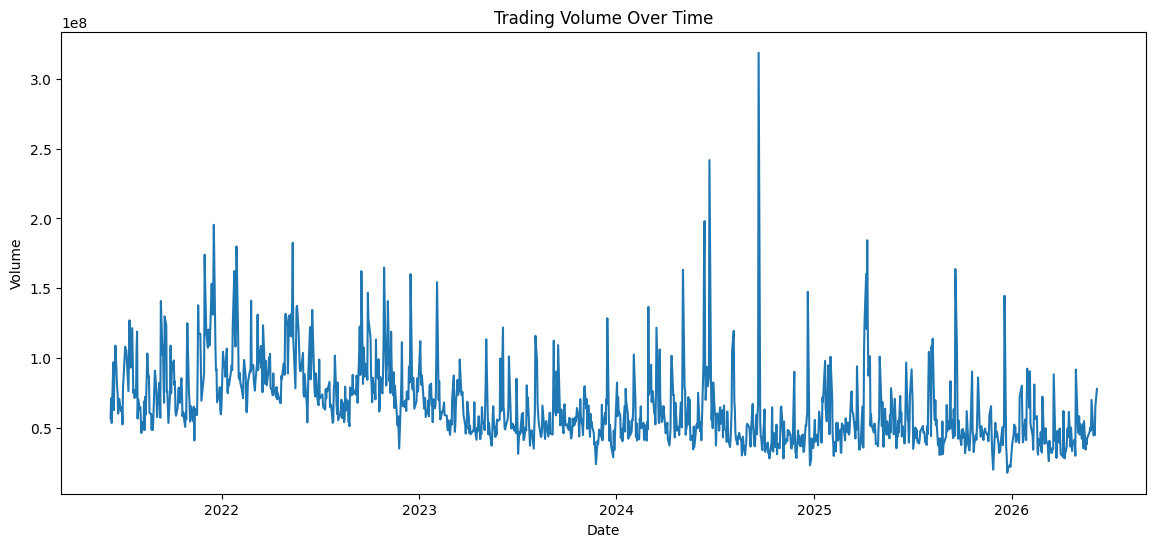

In [39]:
# Visualize trading volume over time
plt.figure(figsize=(14,6))
plt.plot(df.index, df['Volume'])

plt.title('Trading Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Volume')

plt.show()

In [40]:
df.groupby('Year')['Daily_Return'].mean()

Year
2021    0.245343
2022   -0.096961
2023    0.167797
2024    0.116434
2025    0.055293
2026    0.109117
Name: Daily_Return, dtype: float64

In [41]:
df.groupby('Month')['Daily_Return'].mean().sort_values(ascending=False)

Month
July         0.306855
November     0.265184
May          0.205178
October      0.183315
June         0.169115
August       0.112234
February     0.005245
March        0.004515
December    -0.006703
April       -0.022296
January     -0.044770
September   -0.162246
Name: Daily_Return, dtype: float64

In [42]:
# Calculate average monthly closing prices
monthly_close = df['Close'].resample('ME').mean()

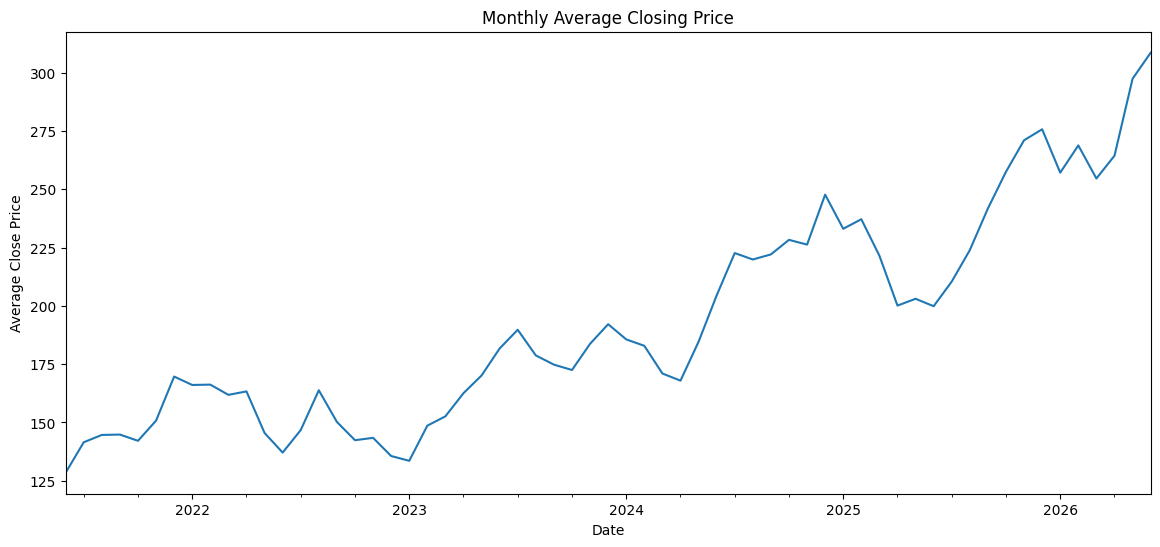

In [43]:
# Visualize monthly average closing prices
plt.figure(figsize=(14,6))
monthly_close.plot()

plt.title('Monthly Average Closing Price')
plt.ylabel('Average Close Price')

plt.show()

In [44]:
# Calculate monthly trading volume
monthly_volume = df['Volume'].resample('ME').sum()

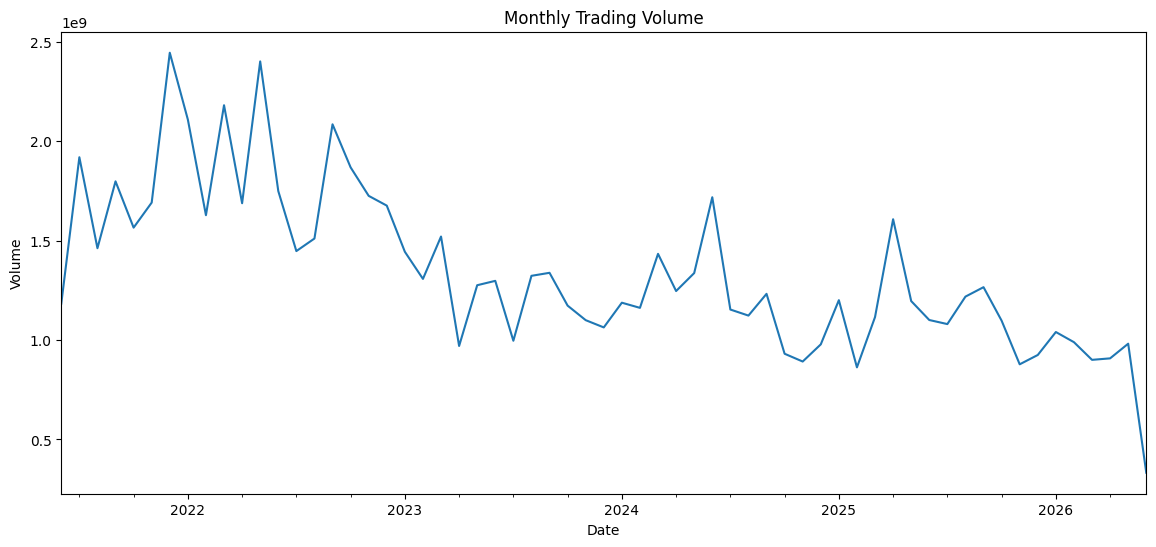

In [45]:
# Visualize monthly trading volume
plt.figure(figsize=(14,6))
monthly_volume.plot()

plt.title('Monthly Trading Volume')
plt.ylabel('Volume')

plt.show()

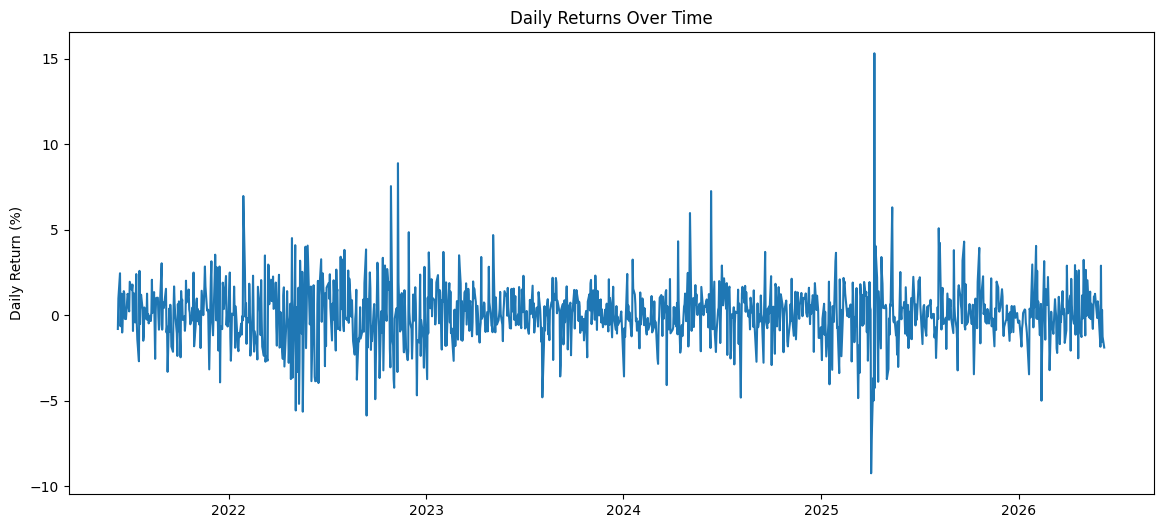

In [46]:
# Visualize daily returns over time
plt.figure(figsize=(14,6))
plt.plot(df.index, df['Daily_Return'])

plt.title('Daily Returns Over Time')
plt.ylabel('Daily Return (%)')

plt.show()

**Feature Engineering**

In [47]:
# Calculate the 7-day moving average of closing prices
df['MA_7'] = df['Close'].rolling(window=7).mean()

In [48]:
# Calculate the 30-day moving average of closing prices
df['MA_30'] = df['Close'].rolling(window=30).mean()

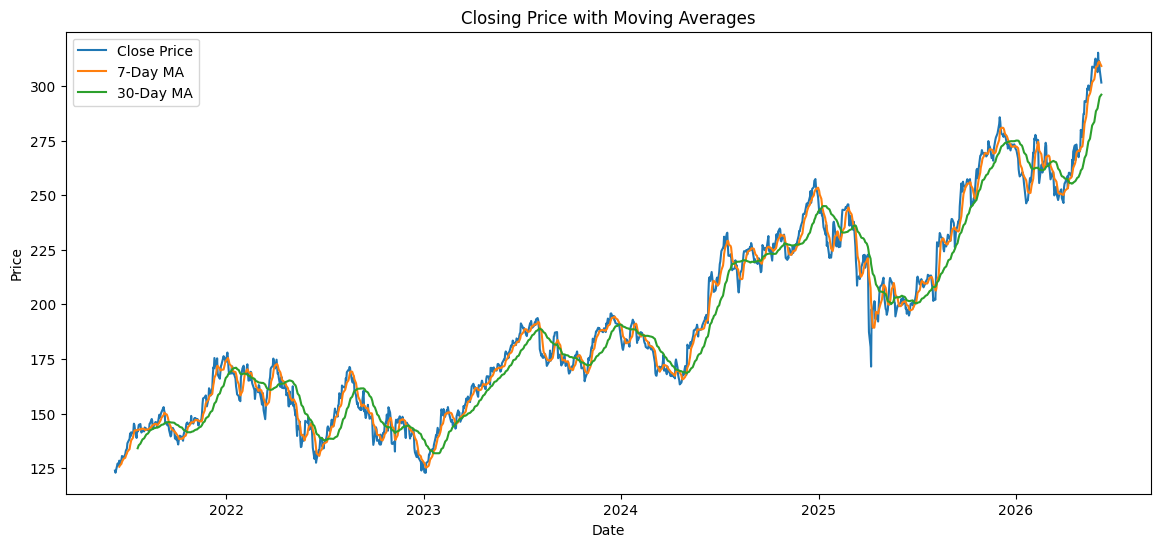

In [49]:
# Visualize closing prices alongside 7-day and 30-day moving averages
plt.figure(figsize=(14,6))

plt.plot(df.index, df['Close'], label='Close Price')
plt.plot(df.index, df['MA_7'], label='7-Day MA')
plt.plot(df.index, df['MA_30'], label='30-Day MA')

plt.title('Closing Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price')

plt.legend()

plt.show()

In [50]:
# Calculate 30-day rolling volatility using daily returns
df['Volatility_30'] = (
    df['Daily_Return']
    .rolling(window=30)
    .std()
)

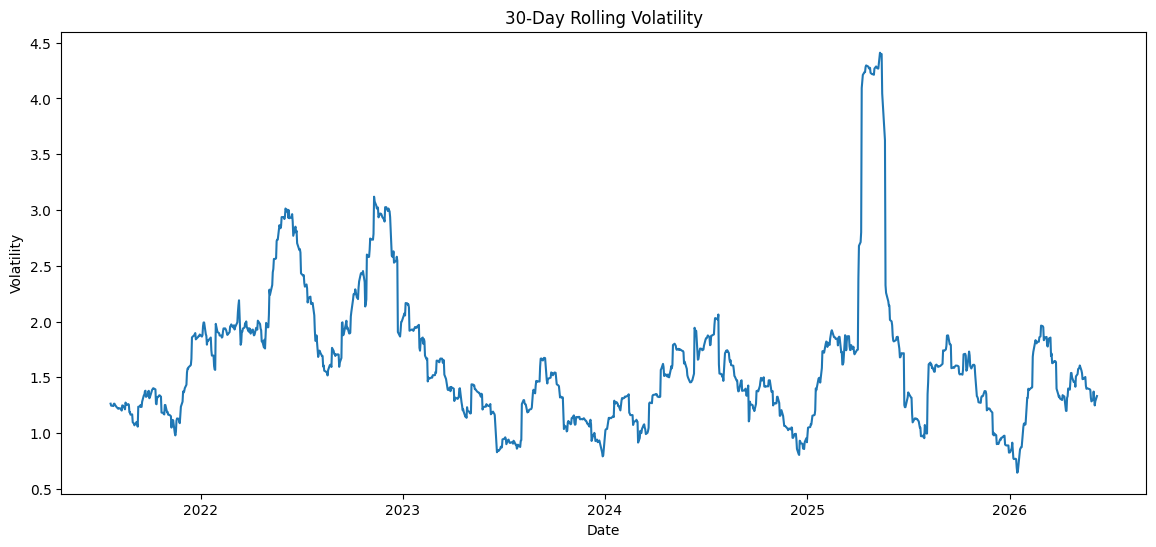

In [51]:
# Visualize 30-day rolling volatility over time
plt.figure(figsize=(14,6))

plt.plot(df.index, df['Volatility_30'])

plt.title('30-Day Rolling Volatility')
plt.xlabel('Date')
plt.ylabel('Volatility')

plt.show()

In [52]:
# Generate summary statistics for rolling volatility
df['Volatility_30'].describe()

count    1225.000000
mean        1.629135
std         0.627461
min         0.644796
25%         1.231970
50%         1.512619
75%         1.859714
max         4.410008
Name: Volatility_30, dtype: float64

In [53]:
# Display the most volatile trading days
df[['Volatility_30']].sort_values(
    by='Volatility_30',
    ascending=False
).head(10)

Price,Volatility_30
Date,
2025-05-12,4.410008
2025-05-13,4.399075
2025-05-14,4.398149
2025-05-15,4.397965
2025-04-17,4.296239
2025-05-05,4.286786
2025-04-21,4.285236
2025-04-16,4.281848
2025-05-06,4.279223


In [54]:
# Calculate monthly percentage returns
monthly_return = monthly_close.pct_change() * 100

In [55]:
# Display monthly return statistics
monthly_return.describe()

count    60.000000
mean      1.646056
std       5.979342
min     -10.920225
25%      -2.146933
50%       1.600110
75%       6.437169
max      12.540205
Name: Close, dtype: float64

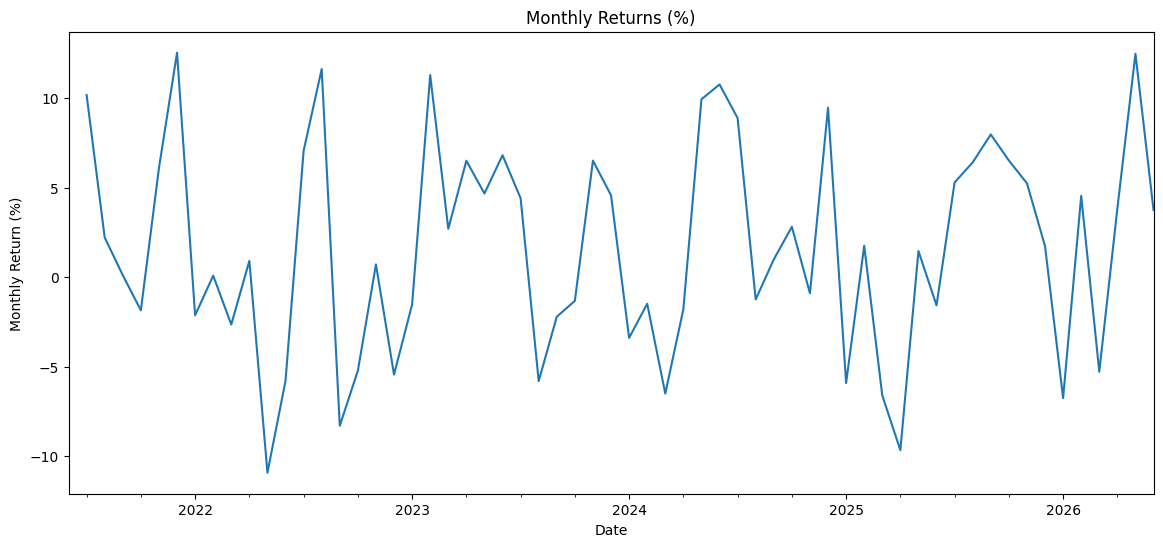

In [56]:
# Visualize monthly returns
plt.figure(figsize=(14,6))
monthly_return.plot()

plt.title('Monthly Returns (%)')
plt.ylabel('Monthly Return (%)')

plt.show()

In [57]:
# Average closing price by year
df.groupby('Year')['Close'].mean()

Year
2021    146.737946
2022    151.805449
2023    170.194612
2024    205.457393
2025    231.349891
2026    270.455784
Name: Close, dtype: float64

In [58]:
# Average trading volume by year
df.groupby('Year')['Volume'].mean()

Year
2021    8.376460e+07
2022    8.791038e+07
2023    5.922355e+07
2024    5.710678e+07
2025    5.417578e+07
2026    4.768656e+07
Name: Volume, dtype: float64

In [59]:
df.head()

Price,Close,High,Low,Open,Volume,Trading_Range,Daily_Price_Change,Pct_Price_Change,Daily_Return,Year,Month_Num,Month,Quarter,Day_Name,MA_7,MA_30,Volatility_30
Date,,,,,,,,,,,,,,,,,
2021-06-09,123.920227,124.524576,123.325628,123.998209,56877900,1.198948,-0.077982,-0.062890,NaN,2021,6,June,2,Wednesday,NaN,NaN,NaN
2021-06-10,122.925957,124.953442,122.760251,123.812977,71186400,2.193192,-0.887020,-0.716420,-0.802347,2021,6,June,2,Thursday,NaN,NaN,NaN
2021-06-11,124.134666,124.222398,122.916226,123.335370,53522400,1.306172,0.799296,0.648067,0.983283,2021,6,June,2,Friday,NaN,NaN,NaN
2021-06-14,127.185600,127.244083,123.861701,124.592765,96906500,3.382382,2.592836,2.081048,2.457761,2021,6,June,2,Monday,NaN,NaN,NaN
2021-06-15,126.366844,127.302613,126.123156,126.659273,62746300,1.179456,-0.292429,-0.230878,-0.643749,2021,6,June,2,Tuesday,NaN,NaN,NaN


In [60]:
df[['MA_7', 'MA_30', 'Volatility_30']].isnull().sum()

Price
MA_7              6
MA_30            29
Volatility_30    30
dtype: int64

In [62]:
# Dashboard dataset with rolling-calculation NaNs removed
df_dashboard = df.dropna()

In [63]:
df_dashboard.isnull().sum()

Price
Close                 0
High                  0
Low                   0
Open                  0
Volume                0
Trading_Range         0
Daily_Price_Change    0
Pct_Price_Change      0
Daily_Return          0
Year                  0
Month_Num             0
Month                 0
Quarter               0
Day_Name              0
MA_7                  0
MA_30                 0
Volatility_30         0
dtype: int64

In [64]:
df_export = df_dashboard.reset_index()

df_export.to_csv(
    r"C:\Users\adero\Downloads\New Projects\AnalystLab Africa\Week 6\apple_stock_cleaned.csv",
    index=False
)